### **Proyecto:** Clasificación — Bank Marketing  
### **Dataset:** [Bank Marketing - UCI ML Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
### **Objetivo:** Predecir cual perfil de cliente presenta mayor probabilidad a suscribir un depósito a plazo fijo (`y` = Alta probabilidad, Media y Baja), para reducir costes de las campañas de marketing.
---
### 🎯 ¿Por qué este dataset?
### El dataset Bank Marketing recoge datos reales de campañas de marketing telefónico de un banco portugués.  
### Es un problema de **clasificación**: queremos predecir cual perfil de cliente presenta mayor probabilidad a contratar un depósito a plazo.  
### Tiene 45.211 registros y 16 variables de entrada, lo que lo hace suficientemente grande para entrenar modelos robustos.
---

### **1. Cargar dataset y importar librerias**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df= pd.read_csv("../data/raw/bank-full.csv", sep= ";")

### **2. Visualizar DataFrame y tipos de datos**

In [ ]:
# Visualizar 5 primeras filas del dataset
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# Visualizar 5 últimas filas del dataset
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [ ]:
# Visualizar cantidad de lineas y columnas del dataset
df.shape

(45211, 17)

In [ ]:
# Info general del dataset (tipos de datos)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [ ]:
# Visualiza la descripcion de la distribuicion de las varibales cuantitativas (numericas)
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
# Visualiza la descripcion de la distribuicion de las varibales cualitativas (categoricas)
df.select_dtypes(include='str').describe()


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [ ]:
# Visualiza la presencia de valores nulos en el dataset
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

,Cantidad unknown,% del total
poutcome,36959.0,81.75
contact,13020.0,28.80
education,1857.0,4.11
job,288.0,0.64



 Estas columnas tienen valores 'unknown' que deberán tratarse en el preprocesamiento.


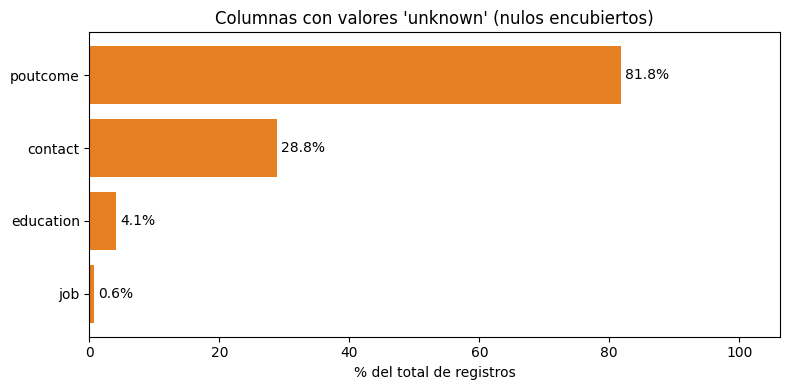

In [57]:
# Visualiza los valores nulos encubiertos como 'unknown'
# Tabla
cols_categoricas = df.select_dtypes(include='str').columns
unknown_counts = {}
for col in cols_categoricas:
    n_unknown = (df[col] == 'unknown').sum()
    pct = round(n_unknown / len(df) * 100, 2)
    if n_unknown > 0:
        unknown_counts[col] = {'Cantidad unknown': n_unknown, '% del total': pct}
if unknown_counts:
    display(pd.DataFrame(unknown_counts).T.sort_values('Cantidad unknown', ascending=False))
    print("\n Estas columnas tienen valores 'unknown' que deberán tratarse en el preprocesamiento.")
else:
    print("No se encontraron valores 'unknown' en columnas categóricas.")

# Gráfico
if unknown_counts:
    unk_df = pd.DataFrame(unknown_counts).T.reset_index()
    unk_df.columns = ['Columna', 'Cantidad', 'Porcentaje']
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(unk_df['Columna'], unk_df['Porcentaje'], color='#e67e22')
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in unk_df['Porcentaje']], padding=3)
    ax.set_xlabel('% del total de registros')
    ax.set_title("Columnas con valores 'unknown' (nulos encubiertos)")
    ax.set_xlim(0, unk_df['Porcentaje'].max() * 1.3)
    plt.tight_layout()
    plt.show()

In [58]:
# Visualizar presencia de valores duplicados
n_duplicados = df.duplicated().sum()
print(f'  Filas duplicadas : {n_duplicados:,}')

  Filas duplicadas : 0


---
#### CONCLUSION DE LA EXPLORACIÓN INICIAL
---
#### 🔑 Hallazgos principales:
| # | Hallazgo | Impacto | Acción recomendada |
|---|----------|---------|--------------------|
| 1 | El dataset tiene **45.211 filas y 17 columnas** | Dataset amplio y suficiente para ML | Ninguna |
| 2 | **No hay valores NaN reales**, pero hay `'unknown'` en varias columnas | Nulos encubiertos | Tratar en preprocesamiento: imputar o crear categoría propia |
| 3 | La columna `contact` tiene el mayor % de `'unknown'` | Media-alta | Evaluar si imputar o eliminar |
| 4 | La columna `pdays` tiene valor -1 para clientes no contactados anteriormente | Valor especial | Crear una variable binaria `fue_contactado_antes` |
| 5 | `duration` es la última duración de llamada — **dato que no se conoce antes de hacer la llamada** | Data leakage potencial | Evaluar si incluirla o excluirla del modelo |
| 6 | No se detectaron columnas tipo ID ni filas duplicadas | ✅ | Ninguna |
---
#### ⚠️ Puntos críticos:
##### **1. La columna `duration` es problemática:**  
##### Indica la duración de la última llamada en segundos. El problema es que **no se puede conocer antes de hacer la llamada**, así que usarla para predecir si el cliente va a suscribir sería hacer trampa (data leakage). El equipo debe decidir si excluirla del modelo o mantenerla con esta advertencia documentada.
##### **2. Los valores `'unknown'`:**  
##### En lugar de NaN reales, este dataset usa la cadena `'unknown'` para indicar información desconocida. En el preprocesamiento hay que decidir si tratarlos como una categoría más o imputarlos con la moda de cada columna.
---

### **3. Analisis Univariado**

🎯 Distribución de la variable objetivo:



,Cantidad,Porcentaje (%)
y,,
no,39922,88.3
yes,5289,11.7


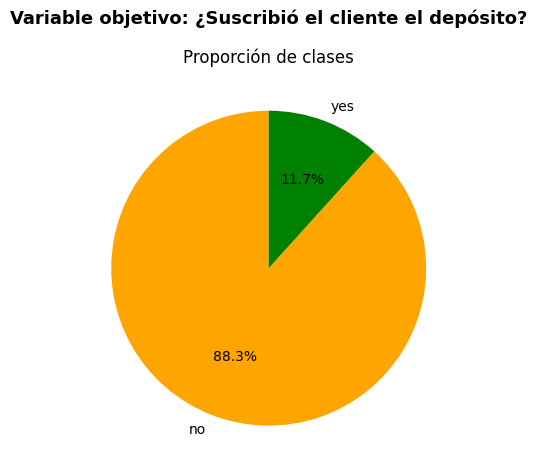


⚠️ DESBALANCEO DETECTADO: ratio 7.5:1 entre clases.
→ Considerar técnicas de balanceo en el preprocesamiento (SMOTE, class_weight, etc.)


In [47]:
target_col = 'y'   # ← nombre de la variable objetivo
conteo = df[target_col].value_counts()
porcentaje = df[target_col].value_counts(normalize=True).mul(100).round(2)
print('🎯 Distribución de la variable objetivo:\n')
resumen_target = pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': porcentaje})
display(resumen_target)

# Gráfico circular
plt.pie(conteo.values, labels=conteo.index, autopct='%1.1f%%', colors=['orange', 'green'], startangle=90)
plt.title('Proporción de clases')
plt.suptitle('Variable objetivo: ¿Suscribió el cliente el depósito?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
ratio = conteo.max() / conteo.min()
if ratio > 3:
    print(f'\n⚠️ DESBALANCEO DETECTADO: ratio {ratio:.1f}:1 entre clases.')
    print('→ Considerar técnicas de balanceo en el preprocesamiento (SMOTE, class_weight, etc.)')
else:
    print(f'\n✅ Las clases están razonablemente balanceadas (ratio {ratio:.1f}:1).')